# Fifty, Fifty & Moore LLP

In [1]:
import pandas as pd
from sqlalchemy import create_engine

# SQLAlchemy engine
engine = create_engine(
    'mysql+mysqlconnector://root:
)

def run_query(sql, columns=None):
    with engine.connect() as conn:
        df = pd.read_sql(sql, conn)
    if columns:
        df.columns = columns
    return df

print("engine ready — connected to divorce_law_firm_db.")

engine ready — connected to divorce_law_firm_db.


## Query 1

In [12]:
sql_q1 = "SELECT * FROM COURT"

df_court = run_query(sql_q1)

# Renaming columns labels
df_court.columns = ['Court_ID', 'Jurisdiction']

df_court.head()

,Court_ID,Jurisdiction
0,1,Jurisdiction 01
1,2,Jurisdiction 02
2,3,Jurisdiction 03
3,4,Jurisdiction 04
4,5,Jurisdiction 05


## Query 2

In [13]:
sql_q2 = """
SELECT * 
FROM BILLING
WHERE TASK in ('Drafting', 'Research')
"""

df_task_billing = run_query(sql_q2)


df_task_billing.columns = ['Bill_ID', 'Description', 'Task', 'Fee', 'Docket_NR']

df_task_billing.head()

,Bill_ID,Description,Task,Fee,Docket_NR
0,1,Drafting Pleading,Drafting,750.0,101
1,3,Research,Research,1200.0,102
2,7,Drafting Pleading,Drafting,960.0,105
3,8,Research,Research,1650.0,105
4,11,Drafting Pleading,Drafting,360.0,107


## Query 3

In [15]:
sql_q3 = """
SELECT LT.LEGAL_ID, LT.NAME, LT.HOURLY_RATE, A.JURIS_NO
FROM LEGAL_TEAM LT, ATTORNEY A
WHERE LT.LEGAL_ID = A.LEGAL_ID
ORDER BY LT.HOURLY_RATE DESC
"""

df_lawyer_rates = run_query(sql_q3)
df_lawyer_rates.columns = ['Legal_ID', 'Lawyer_Name', 'Hourly_Rate', 'Juris_No']

df_lawyer_rates.head()

,Legal_ID,Lawyer_Name,Hourly_Rate,Juris_No
0,1,Lawyer 1,300.0,J-1001
1,2,Lawyer 2,300.0,J-1002
2,3,Lawyer 3,300.0,J-1003
3,4,Lawyer 4,300.0,J-1004
4,5,Lawyer 5,300.0,J-1005


## Query 4

In [16]:
sql_q4 = """
SELECT DOCKET_NR,
COUNT(BILL_ID) AS TOTAL_BILLS,
SUM(FEE) AS TOTAL_FEES,
AVG(FEE) AS AVG_FEE
FROM BILLING
GROUP BY DOCKET_NR
ORDER BY TOTAL_FEES DESC
"""

df_billing = run_query(sql_q4)
df_billing.columns = ['Docket_Nr', 'Total_Bills', 'Total_Fees', 'Avg_Fee']


df_billing.head()

,Docket_Nr,Total_Bills,Total_Fees,Avg_Fee
0,113,9,9180.0,1020.000000
1,105,11,7298.0,663.454545
2,103,10,6450.0,645.000000
3,108,10,5754.0,575.400000
4,117,9,5370.0,596.666667


## Query 5

In [17]:
sql_q5 = """
SELECT  PARTY_ID,
        NAME,
        ANNUAL_INCOME,
        EMPLOYMENT_STATUS
FROM PARTY
WHERE ANNUAL_INCOME > (
    SELECT AVG(ANNUAL_INCOME)
    FROM PARTY
)
ORDER BY ANNUAL_INCOME DESC
"""

df_high_income = run_query(sql_q5)
df_high_income.columns = ['Party_ID', 'Party_Name', 'Annual_Income', 'Employment_Status']

df_high_income.head()

,Party_ID,Party_Name,Annual_Income,Employment_Status
0,40,Client 40,70000.0,Full-time
1,39,Client 39,69000.0,Unemployed
2,38,Client 38,68000.0,Part-time
3,37,Client 37,67000.0,Full-time
4,36,Client 36,66000.0,Unemployed


## Query 6

In [18]:
sql_q6 = """
SELECT
    PF.PARTY_ID,
    SUM(CASE WHEN F.TYPE = 'Asset' THEN F.AMOUNT ELSE 0 END) AS TOTAL_ASSETS,
    SUM(CASE WHEN F.TYPE = 'Liability' THEN F.AMOUNT ELSE 0 END) AS TOTAL_LIABILITIES,
    SUM(CASE WHEN F.TYPE = 'Asset' THEN F.AMOUNT
             WHEN F.TYPE = 'Liability' THEN -F.AMOUNT
             ELSE 0 END) AS NET_WORTH
FROM (
    SELECT FINANCIAL_ID, VALUE AS AMOUNT, 'Asset' AS TYPE FROM ASSET
    UNION
    SELECT FINANCIAL_ID, BALANCE AS AMOUNT, 'Liability' AS TYPE FROM LIABILITY
) AS F,
PARTY_FINANCIAL PF
WHERE F.FINANCIAL_ID = PF.FINANCIAL_ID
GROUP BY PF.PARTY_ID
ORDER BY NET_WORTH DESC
"""

df_net_worth = run_query(sql_q6)
df_net_worth.columns = ['Party_ID', 'Total_Assets', 'Total_Liabilities', 'Net_Worth']

df_net_worth.head()

,Party_ID,Total_Assets,Total_Liabilities,Net_Worth
0,13,2973732.0,246415.0,2727317.0
1,23,2367752.0,246415.0,2121337.0
2,5,2063547.0,142536.0,1921011.0
3,17,2028239.0,156415.0,1871824.0
4,18,2059348.0,210965.0,1848383.0


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

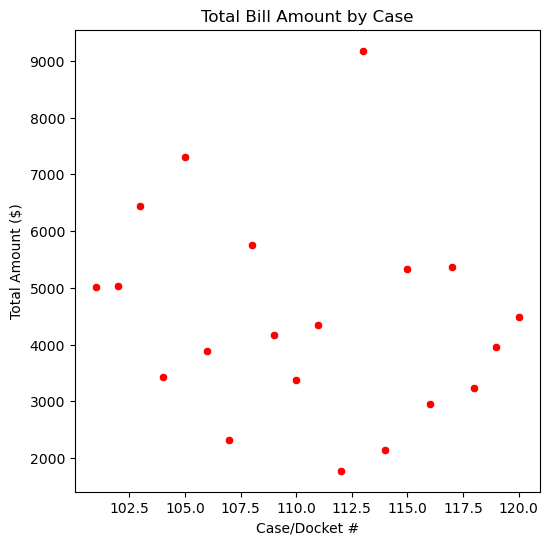

In [9]:
plt.figure(figsize=(6,6))
sns.scatterplot(df_billing, x='Docket_Nr', y='Total_Fees', color='red')

# Set plot title and axis labels
plt.title('Total Bill Amount by Case')
plt.ylabel('Total Amount ($)')
plt.xlabel('Case/Docket #')

plt.show()

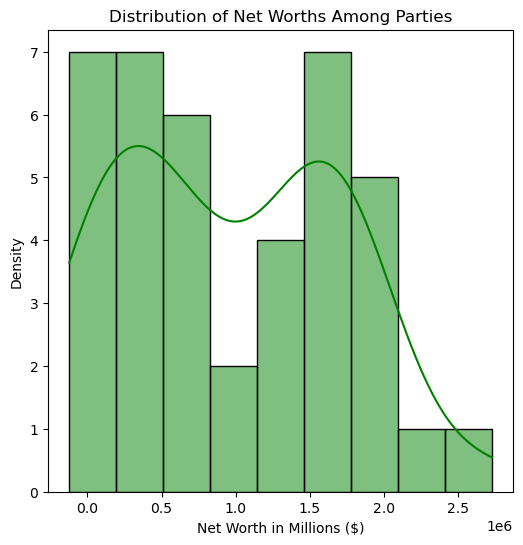

In [10]:
plt.figure(figsize=(6,6))
sns.histplot(df_net_worth['Net_Worth'], bins=9, color='green', kde=True,)

# Set plot title and axis labels
plt.title('Distribution of Net Worths Among Parties')
plt.xlabel('Net Worth in Millions ($)')
plt.ylabel('Density')

plt.show()

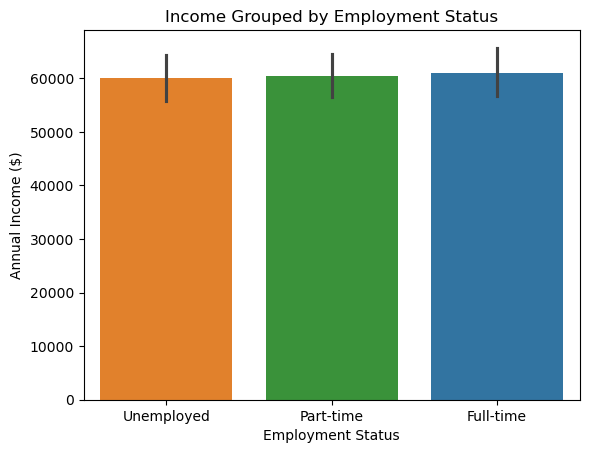

In [11]:
sns.barplot(df_high_income, x="Employment_Status", y="Annual_Income", hue='Employment_Status', 
            legend=False, order=['Unemployed', 'Part-time', 'Full-time'])

# Set plot title and axis labels
plt.title('Income Grouped by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Annual Income ($)')

plt.show()

### The last two graphs show the limitations of the synthetic data generated. We would expect the net worths to be somewhat normally distributed and the incomes grouped by employment status to show a gradation of unempoloyed making the least to full-time making the most 